# Linear classifiers on MNIST

Two minimal linear models trained on MNIST in PyTorch:

1. **Linear classifier** — `nn.Linear(784, 10)` with **no activation**, trained by default with **MSE against one‑hot targets** (i.e. linear regression for classification). A toggle (`LINEAR_LOSS`) lets you switch the loss to cross‑entropy on raw logits.
2. **Multiclass logistic regression** — the same `nn.Linear(784, 10)`, trained with **cross‑entropy** (softmax is folded into the loss).

We then look at:
- per‑model loss curves (separate plots because the two losses live on very different scales);
- a single combined accuracy‑vs‑epoch plot;
- UMAP scatter plots of (a) raw test pixels and (b) each classifier's 10‑D logit "embeddings".

> Educational note: with `LINEAR_LOSS = "ce"` the two models become mathematically identical, and their curves / UMAPs should match up to initialization / shuffle noise.

In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import umap
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_DIR = "./data"
BATCH_SIZE = 256
EPOCHS = 15
LR = 0.1
LINEAR_LOSS = "mse"  # toggle: "mse" (default) or "ce"

print(f"device={DEVICE}, linear_loss={LINEAR_LOSS}")

/datastor2/abao/MLAcademy/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device=cuda, linear_loss=mse


## Load MNIST

We use the standard MNIST split shipped by `torchvision`: 60,000 training images and 10,000 held‑out test images. The first run downloads the dataset into `./data/`; subsequent runs reuse the cache.

In [2]:
to_tensor = transforms.ToTensor()  # uint8 [0,255] -> float32 [0,1], shape (1, 28, 28)

train_ds = datasets.MNIST(DATA_DIR, train=True, download=True, transform=to_tensor)
test_ds = datasets.MNIST(DATA_DIR, train=False, download=True, transform=to_tensor)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

## Brief exploration

Shapes, dtypes, class balance, and a few sample digits.

In [3]:
print(f"train: {len(train_ds)} examples,  test: {len(test_ds)} examples")
print(
    f"image tensor: shape={train_ds.data.shape}, dtype={train_ds.data.dtype}, range=[{train_ds.data.min()}, {train_ds.data.max()}]"
)
print(
    f"label tensor: shape={train_ds.targets.shape}, dtype={train_ds.targets.dtype}, classes={sorted(set(train_ds.targets.tolist()))}"
)

train: 60000 examples,  test: 10000 examples
image tensor: shape=torch.Size([60000, 28, 28]), dtype=torch.uint8, range=[0, 255]
label tensor: shape=torch.Size([60000]), dtype=torch.int64, classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


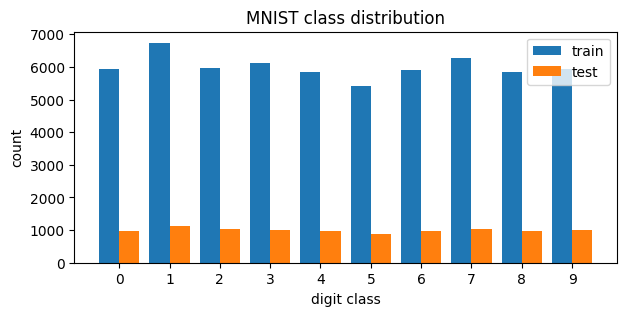

In [4]:
train_counts = Counter(train_ds.targets.tolist())
test_counts = Counter(test_ds.targets.tolist())
classes = sorted(train_counts)

fig, ax = plt.subplots(figsize=(7, 3))
width = 0.4
ax.bar([c - width / 2 for c in classes], [train_counts[c] for c in classes], width=width, label="train")
ax.bar([c + width / 2 for c in classes], [test_counts[c] for c in classes], width=width, label="test")
ax.set_xticks(classes)
ax.set_xlabel("digit class")
ax.set_ylabel("count")
ax.set_title("MNIST class distribution")
ax.legend()
plt.show()

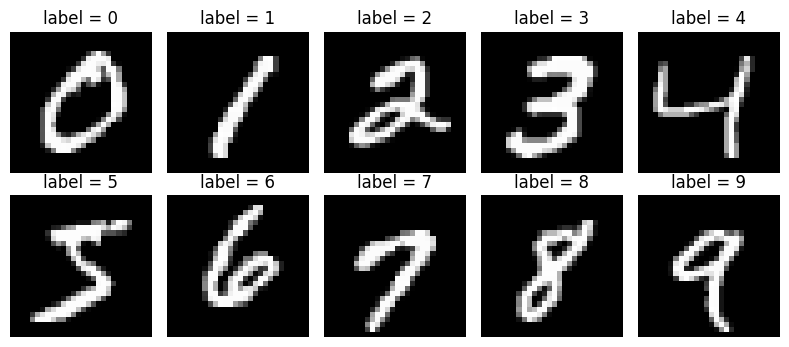

In [5]:
# First example of each class
fig, axes = plt.subplots(2, 5, figsize=(8, 3.5))
for digit, ax in zip(range(10), axes.flat):
    idx = (train_ds.targets == digit).nonzero(as_tuple=True)[0][0].item()
    ax.imshow(train_ds.data[idx], cmap="gray")
    ax.set_title(f"label = {digit}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Two linear models

Both are the same architecture: a single fully‑connected layer mapping the flattened $28\times28 = 784$ pixels to 10 class logits. **The only thing that differs is the loss.**

| Model | Loss | Interpretation |
| --- | --- | --- |
| Linear | MSE vs. one‑hot (default) or CE on logits (toggle) | Linear regression on one‑hot labels |
| LogReg | Cross‑entropy on logits | Multinomial logistic regression |

In [6]:
def make_linear() -> nn.Linear:
    return nn.Linear(28 * 28, 10)


def linear_loss(logits: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    if LINEAR_LOSS == "mse":
        target = F.one_hot(y, num_classes=10).float()
        return F.mse_loss(logits, target)
    if LINEAR_LOSS == "ce":
        return F.cross_entropy(logits, y)
    raise ValueError(f"unknown LINEAR_LOSS: {LINEAR_LOSS!r}")


def logreg_loss(logits: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return F.cross_entropy(logits, y)

## Training loop

Vanilla SGD. After every epoch we make one pass over the full train and test sets to record both **average loss** and **accuracy** for that epoch.

In [7]:
def eval_metrics(model, loader, loss_fn) -> tuple[float, float]:
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x = x.view(x.size(0), -1).to(DEVICE)
            y = y.to(DEVICE)
            logits = model(x)
            total_loss += loss_fn(logits, y).item() * x.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n


def record(history, tr_loss, te_loss, tr_acc, te_acc):
    history["train_loss"].append(tr_loss)
    history["test_loss"].append(te_loss)
    history["train_acc"].append(tr_acc)
    history["test_acc"].append(te_acc)


def train_model(model, loss_fn, train_loader, test_loader, epochs, lr):
    model.to(DEVICE)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

    # epoch 0: untrained baseline
    tr_loss, tr_acc = eval_metrics(model, train_loader, loss_fn)
    te_loss, te_acc = eval_metrics(model, test_loader, loss_fn)
    record(history, tr_loss, te_loss, tr_acc, te_acc)
    print(
        f"epoch  0/{epochs}  "
        f"train_loss={tr_loss:.4f}  test_loss={te_loss:.4f}  "
        f"train_acc={tr_acc:.4f}  test_acc={te_acc:.4f}"
    )

    for epoch in range(epochs):
        model.train()
        for x, y in train_loader:
            x = x.view(x.size(0), -1).to(DEVICE)
            y = y.to(DEVICE)
            opt.zero_grad()
            loss_fn(model(x), y).backward()
            opt.step()
        tr_loss, tr_acc = eval_metrics(model, train_loader, loss_fn)
        te_loss, te_acc = eval_metrics(model, test_loader, loss_fn)
        record(history, tr_loss, te_loss, tr_acc, te_acc)
        print(
            f"epoch {epoch + 1:2d}/{epochs}  "
            f"train_loss={tr_loss:.4f}  test_loss={te_loss:.4f}  "
            f"train_acc={tr_acc:.4f}  test_acc={te_acc:.4f}"
        )
    return history

In [8]:
print("Training linear classifier...")
linear = make_linear()
hist_lin = train_model(linear, linear_loss, train_loader, test_loader, EPOCHS, LR)

print("\nTraining logistic regression...")
logreg = make_linear()
hist_log = train_model(logreg, logreg_loss, train_loader, test_loader, EPOCHS, LR)

Training linear classifier...
epoch  0/15  train_loss=0.1345  test_loss=0.1346  train_acc=0.0557  test_acc=0.0540
epoch  1/15  train_loss=0.0457  test_loss=0.0448  train_acc=0.8293  test_acc=0.8392
epoch  2/15  train_loss=0.0431  test_loss=0.0423  train_acc=0.8391  test_acc=0.8490
epoch  3/15  train_loss=0.0420  test_loss=0.0413  train_acc=0.8423  test_acc=0.8504
epoch  4/15  train_loss=0.0414  test_loss=0.0409  train_acc=0.8444  test_acc=0.8516
epoch  5/15  train_loss=0.0410  test_loss=0.0404  train_acc=0.8470  test_acc=0.8549
epoch  6/15  train_loss=0.0406  test_loss=0.0401  train_acc=0.8502  test_acc=0.8576
epoch  7/15  train_loss=0.0401  test_loss=0.0396  train_acc=0.8543  test_acc=0.8619
epoch  8/15  train_loss=0.0402  test_loss=0.0396  train_acc=0.8542  test_acc=0.8637
epoch  9/15  train_loss=0.0399  test_loss=0.0394  train_acc=0.8562  test_acc=0.8632
epoch 10/15  train_loss=0.0398  test_loss=0.0393  train_acc=0.8556  test_acc=0.8647
epoch 11/15  train_loss=0.0396  test_loss=0.03

## Loss curves (per model)

The two models use different losses (MSE on one‑hot vs. cross‑entropy), so absolute values live on very different scales. We plot each model in its own subplot with its own y‑axis. Solid = train, dashed = test.

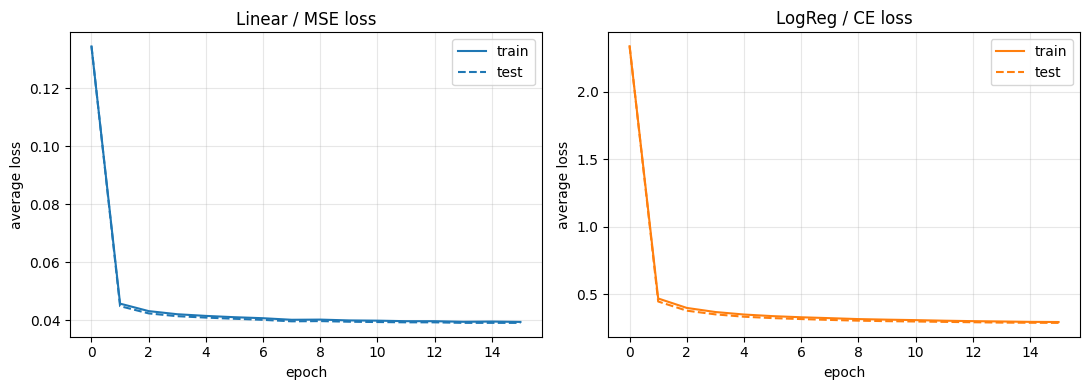

In [9]:
epochs = range(0, EPOCHS + 1)
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 4))

ax_l.plot(epochs, hist_lin["train_loss"], color="C0", linestyle="-", label="train")
ax_l.plot(epochs, hist_lin["test_loss"], color="C0", linestyle="--", label="test")
ax_l.set_title(f"Linear / {LINEAR_LOSS.upper()} loss")
ax_l.set_xlabel("epoch")
ax_l.set_ylabel("average loss")
ax_l.legend()
ax_l.grid(True, alpha=0.3)

ax_r.plot(epochs, hist_log["train_loss"], color="C1", linestyle="-", label="train")
ax_r.plot(epochs, hist_log["test_loss"], color="C1", linestyle="--", label="test")
ax_r.set_title("LogReg / CE loss")
ax_r.set_xlabel("epoch")
ax_r.set_ylabel("average loss")
ax_r.legend()
ax_r.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Accuracy curves (both models, one plot)

Accuracy is comparable across models, so a single shared y‑axis is honest.

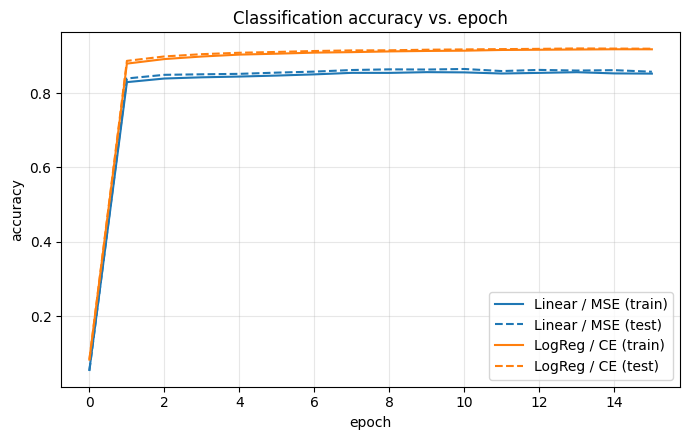

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(epochs, hist_lin["train_acc"], color="C0", linestyle="-", label=f"Linear / {LINEAR_LOSS.upper()} (train)")
ax.plot(epochs, hist_lin["test_acc"], color="C0", linestyle="--", label=f"Linear / {LINEAR_LOSS.upper()} (test)")
ax.plot(epochs, hist_log["train_acc"], color="C1", linestyle="-", label="LogReg / CE (train)")
ax.plot(epochs, hist_log["test_acc"], color="C1", linestyle="--", label="LogReg / CE (test)")
ax.set_xlabel("epoch")
ax.set_ylabel("accuracy")
ax.set_title("Classification accuracy vs. epoch")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Visualizing learned representations with UMAP

We project the 10,000 MNIST test points down to 2‑D with UMAP and color by digit class. Three panels:

1. **Raw pixels** (784‑D) — what UMAP sees with no learning.
2. **Linear classifier logits** (10‑D) — the only representation a single linear layer produces.
3. **LogReg classifier logits** (10‑D).

Even though the two models share the same architecture, they shape the logit space differently. With `LINEAR_LOSS = "ce"` the bottom two panels should look essentially the same.

In [11]:
def collect_embeddings(model, loader):
    model.eval()
    Xs, Ys, Zs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            flat = x.view(x.size(0), -1)
            Xs.append(flat.numpy())
            Ys.append(y.numpy())
            Zs.append(model(flat.to(DEVICE)).cpu().numpy())
    return np.concatenate(Xs), np.concatenate(Ys), np.concatenate(Zs)


X_test, y_test, Z_lin = collect_embeddings(linear, test_loader)
_, _, Z_log = collect_embeddings(logreg, test_loader)
print(f"X_test={X_test.shape}, Z_lin={Z_lin.shape}, Z_log={Z_log.shape}")

X_test=(10000, 784), Z_lin=(10000, 10), Z_log=(10000, 10)


In [12]:
def fit_umap(X):
    return umap.UMAP(n_components=2, random_state=0).fit_transform(X)


print("Fitting UMAP on raw pixels (10000 x 784)... this is the slow one (~30-60s)")
U_raw = fit_umap(X_test)
print("Fitting UMAP on Linear logits (10000 x 10)...")
U_lin = fit_umap(Z_lin)
print("Fitting UMAP on LogReg logits (10000 x 10)...")
U_log = fit_umap(Z_log)

Fitting UMAP on raw pixels (10000 x 784)... this is the slow one (~30-60s)


/datastor2/abao/MLAcademy/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fitting UMAP on Linear logits (10000 x 10)...


/datastor2/abao/MLAcademy/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fitting UMAP on LogReg logits (10000 x 10)...


/datastor2/abao/MLAcademy/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


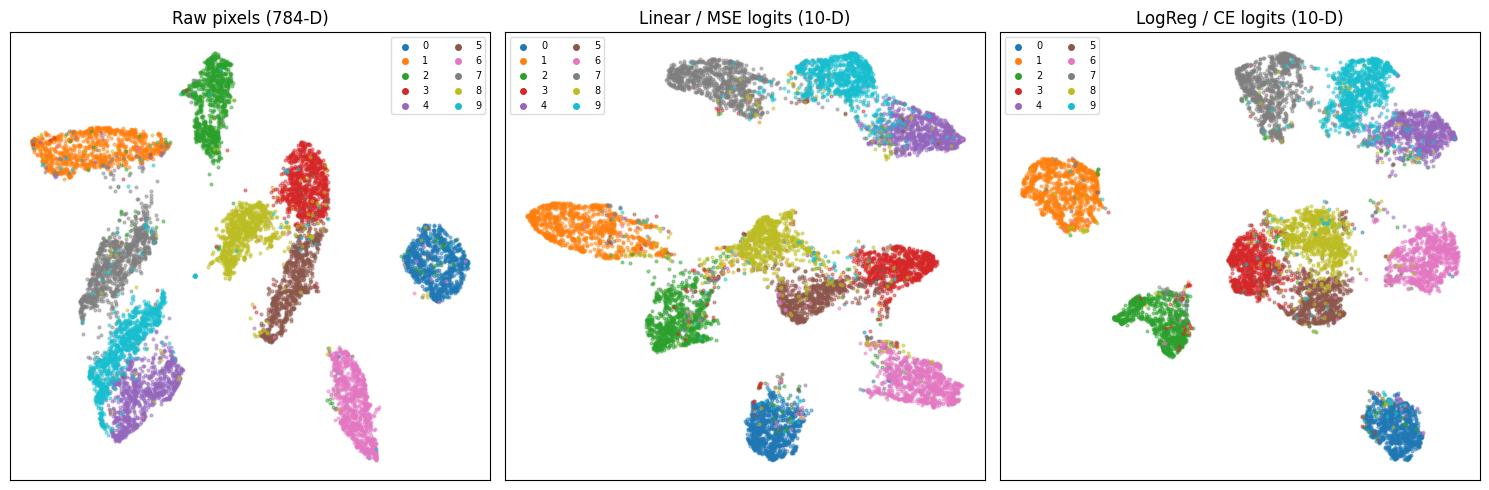

In [13]:
def plot_umap_2d(emb, labels, ax, title):
    cmap = plt.get_cmap("tab10")
    for c in range(10):
        m = labels == c
        ax.scatter(emb[m, 0], emb[m, 1], s=4, alpha=0.45, color=cmap(c), label=str(c))
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    leg = ax.legend(loc="best", fontsize=7, markerscale=2, ncols=2, framealpha=0.7)
    for handle in leg.legend_handles:
        handle.set_alpha(1.0)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_umap_2d(U_raw, y_test, axes[0], "Raw pixels (784-D)")
plot_umap_2d(U_lin, y_test, axes[1], f"Linear / {LINEAR_LOSS.upper()} logits (10-D)")
plot_umap_2d(U_log, y_test, axes[2], "LogReg / CE logits (10-D)")
plt.tight_layout()
plt.show()

**Takeaways**

- Raw‑pixel UMAP already separates digits — MNIST is genuinely easy.
- The linear classifiers' 10‑D logit spaces produce *tighter, more class‑pure* clusters: the learned linear projection has explicitly pulled examples toward their class axis.
- With `LINEAR_LOSS = "ce"`, the Linear and LogReg panels become essentially the same picture — because the two models are then the same model.